## Motor imagery decoding with CSP and LDA and Interpretability (XAI)

## Objective
The goal of this notebook is to build and validate a **Brain-Computer Interface (BCI)** decoder. I transition from cleaned EEG signals to actionable commands by classifying "Left Hand" vs "Right Hand" imagery.

## The algorithmic pipeline
1. **Feature extraction: Common Spatial Patterns (CSP)**. I use CSP to find spatial filters that maximize the variance of one class while minimizing the other. This targets the lateralized Mu/Beta desynchronization.
2. **Classification: Linear Discriminant Analysis (LDA)**. A robust, low-complexity classifier that works effectively with the high-dimensional features produced by CSP.
3. **Validation Strategy**: I use **stratified repeated ShuffleSplit cross-validation** for trial-wise, intra-subject performance estimation. CSP is fitted inside the pipeline on each training split to prevent data leakage.

## Why this matters for Rehabilitation
In a clinical setting, a BCI must be interpretable. I don't just want a black box prediction; I need to verify that the model is actually listening to the **Motor Cortex** and **not to residual noise or muscular artifacts**.

## Setup and loading cleaned data

In [8]:
import mne
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t
from mne.decoding import CSP
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedShuffleSplit, cross_validate
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

CLEAN_DATA_PATH = os.path.join('.', 'cleaned_data', 'A01T_clean-raw.fif')
raw = mne.io.read_raw_fif(CLEAN_DATA_PATH, preload=True)
event_id = {'left': 1, 'right': 2}
events, _ = mne.events_from_annotations(raw)
print(f"Ready to decode {len(events)} trials for Subject 1.")


Opening raw data file .\cleaned_data\A01T_clean-raw.fif...
    Range : 0 ... 671727 =      0.000 ...  2686.908 secs
Ready.
Reading 0 ... 671727  =      0.000 ...  2686.908 secs...
Used Annotations descriptions: [np.str_('foot'), np.str_('left'), np.str_('right'), np.str_('tongue')]
Ready to decode 288 trials for Subject 1.


## Epoching: capturing the imagery window
I avoid the first 0.5s after the cue to exclude visual evoked potentials and focus strictly on the sustained Motor Imagery period (0.5s to 3.5s).

In [9]:
tmin, tmax = 0.5, 3.5 # Focus on the stable imagery period
epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, 
                    baseline=None, preload=True)

# Get data as (n_trials, n_channels, n_times)
labels = epochs.events[:, -1]
data = epochs.get_data(copy=True)

print(f"Data shape: {data.shape} (Trials x Channels x Samples)")

Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 144 events and 751 original time points ...
0 bad epochs dropped
Data shape: (144, 25, 751) (Trials x Channels x Samples)


## CSP + LDA
Combine CSP (feature extraction) and LDA (classifier) into a single pipeline to prevent data leakage.

In [10]:
from sklearn.model_selection import StratifiedShuffleSplit, cross_validate

cv = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
lda = LDA()
clf = Pipeline([('CSP', csp), ('LDA', lda)])

scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro'
}

results = cross_validate(clf, data, labels, cv=cv, scoring=scoring, return_train_score=False)

for metric in scoring:
    values = results[f'test_{metric}']
    print(f"{metric}: {values.mean():.3f} +/- {values.std(ddof=1):.3f}")

classes, counts = np.unique(labels, return_counts=True)
print('\nClass distribution:')
for class_id, count in zip(classes, counts):
    print(f'  Class {class_id}: {count} trials')
print(f'Total trials: {len(labels)}')
print(f'Chance level (uniform binary): {1/len(classes):.1%}')
print(f'Majority-class baseline: {counts.max()/counts.sum():.3f}')


Computing rank from data with rank=None


    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.5e-05 (2.2e-16 eps * 25 dim * 6.3e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covarian

## Neuro-data scientist analysis: spatial filter interpretability

The visualized CSP Patterns represent the **spatial weights the model uses to distinguish between Left and Right hand imagery**.

- **Lateralization**: looking at **key patterns (e.g., CSP1, CSP4, CSP21)**, I observe **strong dipolar activations over the C3 (left) and C4 (right) electrode** positions.

- Physiological grounding: nn neurophysiology, **imagining a right-hand movement triggers a desynchronization in the left hemisphere (C3)**. The **CSP algorithm** successfully **captured these neural signatures**, proving that our feature extraction is biologically informed and not just mathematically coincident.

- **Redundancy** : with **25 patterns**, I notice that the **later filters capture** finer, more **localized noise**. In a **production system**, I could prune these to **improve the signal-to-noise ratio**.

Computing rank from data with rank=None
    Using tolerance 3.8e-05 (2.2e-16 eps * 25 dim * 6.8e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


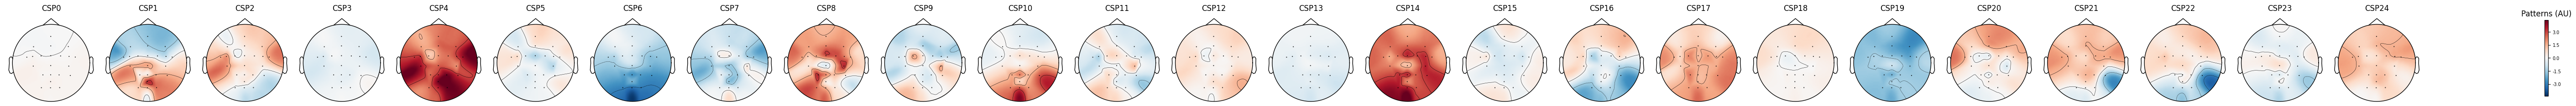

In [11]:
# Fit the CSP to visualize the patterns
csp.fit(data, labels)

# Plot the topographies of the 4 CSP filters
csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)
plt.show()

## Cross-validated confusion matrix
The confusion matrix below is built from the predictions generated on the **test portion of each of the 10 repeated StratifiedShuffleSplit iterations**. It is therefore consistent with the validation procedure used for the reported metrics. Because ShuffleSplit test sets can overlap, a trial may contribute more than once to this aggregated matrix.


Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.5e-05 (2.2e-16 eps * 25 dim * 6.3e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

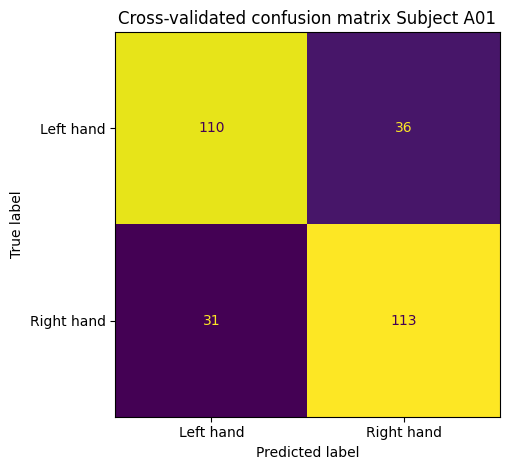

In [12]:
y_true_cv = []
y_pred_cv = []

for train_idx, test_idx in cv.split(data, labels):
    fold_clf = clone(clf)
    fold_clf.fit(data[train_idx], labels[train_idx])
    y_true_cv.extend(labels[test_idx])
    y_pred_cv.extend(fold_clf.predict(data[test_idx]))

y_true_cv = np.asarray(y_true_cv)
y_pred_cv = np.asarray(y_pred_cv)

print(f'Cross-validated test predictions: {len(y_true_cv)}')
print(f'Accuracy on aggregated test predictions: {accuracy_score(y_true_cv, y_pred_cv):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_true_cv, y_pred_cv):.3f}')

print('\nClassification report:')
print(classification_report(y_true_cv, y_pred_cv, labels=classes, target_names=['Left hand', 'Right hand'], digits=3))

cm = confusion_matrix(y_true_cv, y_pred_cv, labels=classes)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Left hand', 'Right hand']).plot(values_format='d', colorbar=False)
plt.title('Cross-validated confusion matrix Subject A01')
plt.tight_layout()
plt.show()


## Evaluation across all subjects
The following analysis applies the **same stratified repeated ShuffleSplit validation procedure** to each cleaned subject. It reports subject-level mean accuracy and variability across the 10 validation splits.

This is still **intra-subject** validation: each subject is trained and evaluated using that subject's own trials. It should not be interpreted as cross-subject generalisation.





In [13]:
cleaned_files = sorted([f for f in os.listdir(os.path.join('.', 'cleaned_data')) if f.endswith('.fif')])

subject_results = []

for sub_file in cleaned_files:
    temp_raw = mne.io.read_raw_fif(os.path.join('.', 'cleaned_data', sub_file), preload=True, verbose=False)
    temp_events, _ = mne.events_from_annotations(temp_raw, verbose=False)
    temp_epochs = mne.Epochs(temp_raw, temp_events, event_id, tmin, tmax, baseline=None, preload=True, verbose=False)
    X = temp_epochs.get_data(copy=True)
    y = temp_epochs.events[:, -1]

    subject_cv = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
    subject_clf = Pipeline([('CSP', CSP(n_components=4, reg=None, log=True, norm_trace=False)), ('LDA', LDA())])
    subject_scores = cross_validate(subject_clf, X, y, cv=subject_cv, scoring={'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1_macro': 'f1_macro'}, return_train_score=False)

    subject_id = sub_file.split('_')[0]
    subject_results.append({
        'subject': subject_id,
        'n_trials': len(y),
        'accuracy_mean': subject_scores['test_accuracy'].mean(),
        'accuracy_sd': subject_scores['test_accuracy'].std(ddof=1),
        'balanced_accuracy_mean': subject_scores['test_balanced_accuracy'].mean(),
        'f1_macro_mean': subject_scores['test_f1_macro'].mean()
    })

results_df = pd.DataFrame(subject_results).sort_values('subject')
print(results_df.to_string(index=False, formatters={'accuracy_mean': '{:.3f}'.format, 'accuracy_sd': '{:.3f}'.format, 'balanced_accuracy_mean': '{:.3f}'.format, 'f1_macro_mean': '{:.3f}'.format}))
print(f"\nMean subject accuracy: {results_df['accuracy_mean'].mean():.3f}")
print(f"Between-subject SD: {results_df['accuracy_mean'].std(ddof=1):.3f}")


Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.5e-05 (2.2e-16 eps * 25 dim * 6.3e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.5e-05 (2.2e-16 eps * 25 dim * 6.3e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

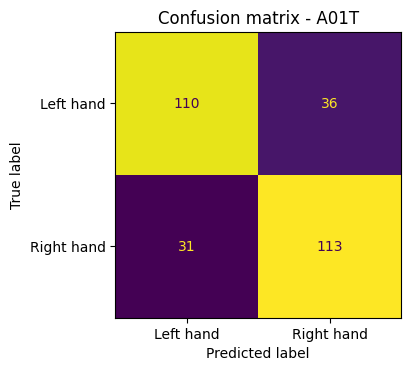

Computing rank from data with rank=None
    Using tolerance 4.9e-05 (2.2e-16 eps * 25 dim * 8.8e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.7e-05 (2.2e-16 eps * 25 dim * 8.5e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.7e-05 (2.2e-16 eps * 25 dim * 8.4e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

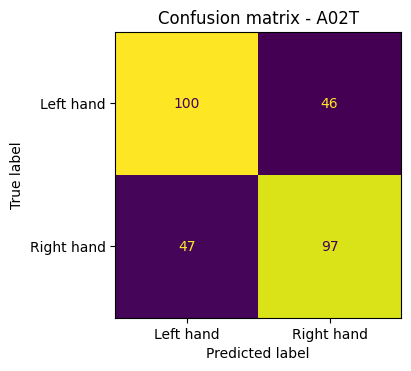

Computing rank from data with rank=None
    Using tolerance 5.2e-05 (2.2e-16 eps * 25 dim * 9.3e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.2e-05 (2.2e-16 eps * 25 dim * 9.4e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.1e-05 (2.2e-16 eps * 25 dim * 9.3e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

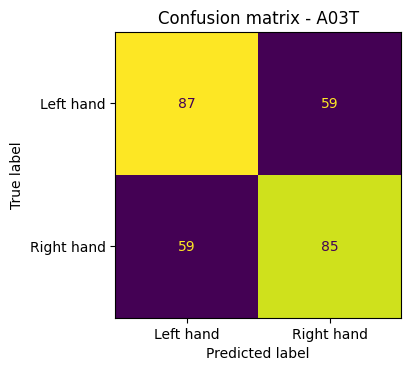

Computing rank from data with rank=None
    Using tolerance 2.9e-05 (2.2e-16 eps * 25 dim * 5.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.9e-05 (2.2e-16 eps * 25 dim * 5.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.8e-05 (2.2e-16 eps * 25 dim * 5.1e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

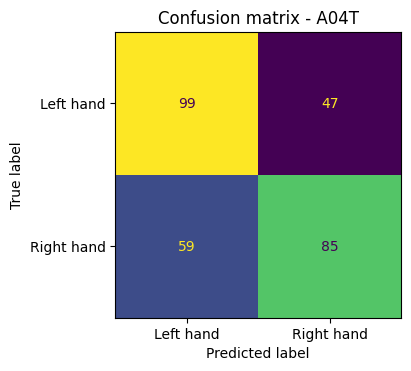

Computing rank from data with rank=None
    Using tolerance 4.5e-05 (2.2e-16 eps * 25 dim * 8.1e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.6e-05 (2.2e-16 eps * 25 dim * 8.3e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.5e-05 (2.2e-16 eps * 25 dim * 8.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

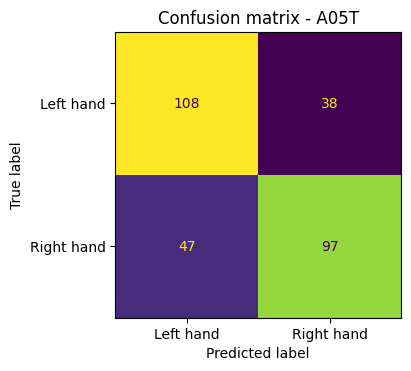

Computing rank from data with rank=None
    Using tolerance 4.2e-05 (2.2e-16 eps * 25 dim * 7.6e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.2e-05 (2.2e-16 eps * 25 dim * 7.5e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.1e-05 (2.2e-16 eps * 25 dim * 7.5e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

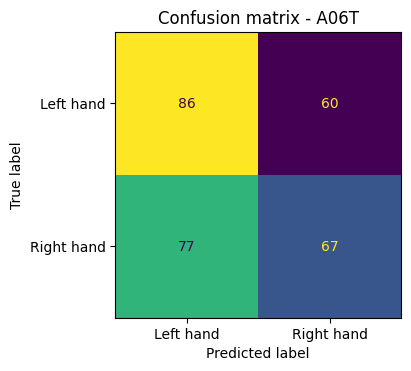

Computing rank from data with rank=None
    Using tolerance 4e-05 (2.2e-16 eps * 25 dim * 7.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.1e-05 (2.2e-16 eps * 25 dim * 7.3e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.8e-05 (2.2e-16 eps * 25 dim * 6.9e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIR

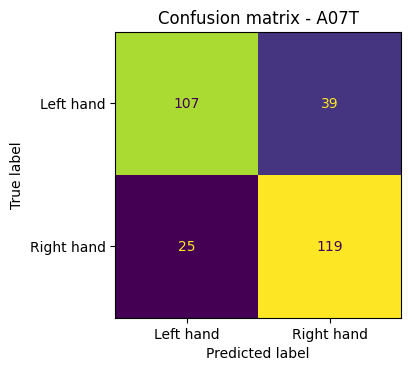

Computing rank from data with rank=None
    Using tolerance 6.1e-05 (2.2e-16 eps * 25 dim * 1.1e+10  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 6.1e-05 (2.2e-16 eps * 25 dim * 1.1e+10  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 6.2e-05 (2.2e-16 eps * 25 dim * 1.1e+10  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

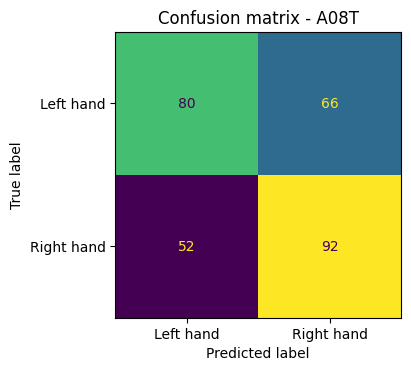

Computing rank from data with rank=None
    Using tolerance 4.8e-05 (2.2e-16 eps * 25 dim * 8.7e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.8e-05 (2.2e-16 eps * 25 dim * 8.7e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.8e-05 (2.2e-16 eps * 25 dim * 8.7e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

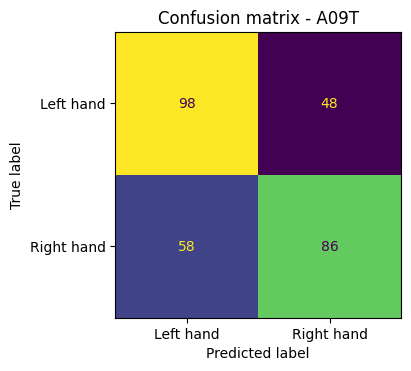


Overall confusion matrix across all subjects:
[[875 439]
 [455 841]]


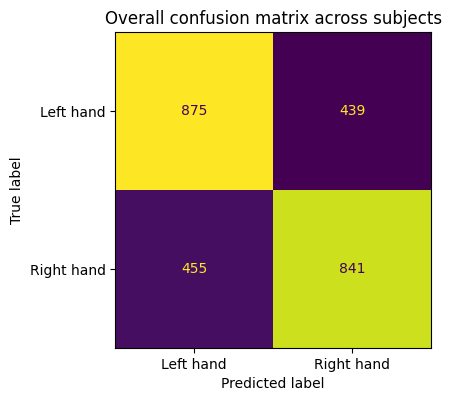

In [15]:
# Confusion matrices per subject and one overall aggregate matrix
# Reuses existing variables: cleaned_files, event_id, tmin, tmax, clf, classes, os, np, plt, mne

all_y_true = []
all_y_pred = []

subject_cm = {}

for sub_file in cleaned_files:
    temp_raw = mne.io.read_raw_fif(
        os.path.join('.', 'cleaned_data', sub_file),
        preload=True, verbose=False
    )
    temp_events, _ = mne.events_from_annotations(temp_raw, verbose=False)
    temp_epochs = mne.Epochs(
        temp_raw, temp_events, event_id, tmin, tmax,
        baseline=None, preload=True, verbose=False
    )
    X = temp_epochs.get_data(copy=True)
    y = temp_epochs.events[:, -1]

    subject_cv = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

    y_true_subject = []
    y_pred_subject = []

    for train_idx, test_idx in subject_cv.split(X, y):
        fold_clf = clone(clf)
        fold_clf.fit(X[train_idx], y[train_idx])
        y_true_subject.extend(y[test_idx])
        y_pred_subject.extend(fold_clf.predict(X[test_idx]))

    y_true_subject = np.asarray(y_true_subject)
    y_pred_subject = np.asarray(y_pred_subject)

    cm = confusion_matrix(y_true_subject, y_pred_subject, labels=classes)
    subject_id = sub_file.split('_')[0]
    subject_cm[subject_id] = cm

    all_y_true.extend(y_true_subject)
    all_y_pred.extend(y_pred_subject)

    print(f"\n{subject_id}")
    print(f"Accuracy: {accuracy_score(y_true_subject, y_pred_subject):.3f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_true_subject, y_pred_subject):.3f}")
    print(cm)

    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Left hand', 'Right hand']
    ).plot(ax=ax, values_format='d', colorbar=False)
    ax.set_title(f'Confusion matrix - {subject_id}')
    plt.tight_layout()
    plt.show()

all_y_true = np.asarray(all_y_true)
all_y_pred = np.asarray(all_y_pred)

overall_cm = confusion_matrix(all_y_true, all_y_pred, labels=classes)

print("\nOverall confusion matrix across all subjects:")
print(overall_cm)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=overall_cm,
    display_labels=['Left hand', 'Right hand']
).plot(ax=ax, values_format='d', colorbar=False)
ax.set_title('Overall confusion matrix across subjects')
plt.tight_layout()
plt.show()

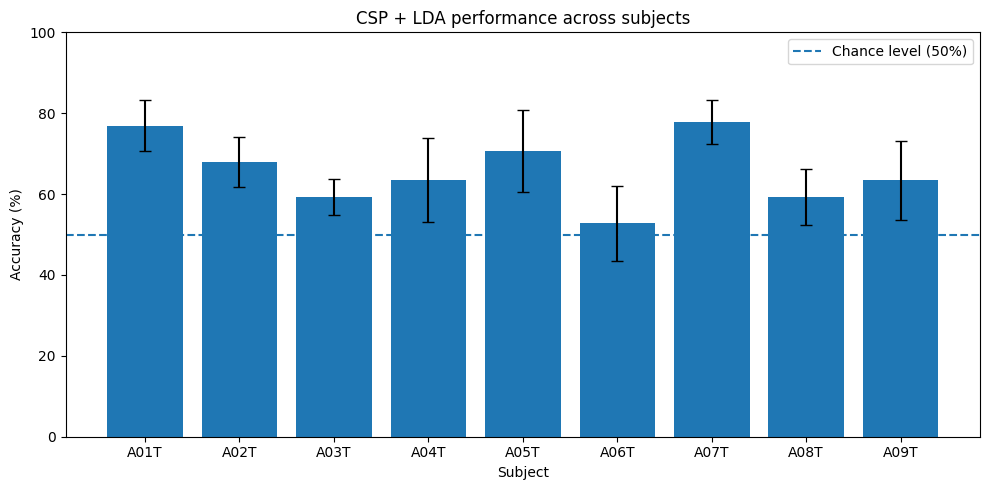

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df['subject'],
    results_df['accuracy_mean'] * 100,
    yerr=results_df['accuracy_sd'] * 100,
    capsize=4
)

plt.axhline(50, linestyle='--', label='Chance level (50%)')

plt.xlabel('Subject')
plt.ylabel('Accuracy (%)')
plt.title('CSP + LDA performance across subjects')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Scaling to all subjects

The cross-validated confusion matrices across all 9 subjects provide a
more detailed view of the CSP + LDA classification performance.

**High-performing subjects (e.g., A01 and A07)** show a clear diagonal
dominance in the confusion matrices, indicating that Left- and Right-hand
motor imagery trials are generally well separated by the learned CSP
representations.

Across subjects, the off-diagonal errors are generally relatively balanced,
which is consistent with the similar Accuracy and Balanced Accuracy values
reported in the quantitative evaluation. This suggests that there is no
strong systematic bias toward predicting one class over the other.

However, **performance varies substantially between subjects**. Accuracy
ranges from approximately **52.8% (A06)** to **77.9% (A07)**, with a mean
subject accuracy of **65.7%** and a between-subject standard deviation of
**8.4 percentage points**.

Lower-performing subjects (e.g., A06, A03 and A08) show weaker separation
between the two classes. This inter-subject variability highlights an
important limitation of motor-imagery EEG decoding, the quality and
separability of the neural patterns can differ considerably across
individuals.

These results should be interpreted as **within-subject performance**,
since each subject is evaluated using training and test trials from the
same subject. Therefore, the reported results do not demonstrate
generalization to previously unseen subjects.